# Import Library

In [1]:
# ============================================================
# IMPORT LIBRARY
# ============================================================
import os
import sys
import pickle
import warnings
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE
import optuna
import mlflow
import mlflow.sklearn

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Python:", sys.executable)
print("Folder kerja:", os.getcwd())

Python: c:\Users\Lenovo\AppData\Local\Programs\Python\Python310\python.exe
Folder kerja: c:\Users\Lenovo\OneDrive - Politeknik Elektronika Negeri Surabaya\PENS ANJAY\SEMESTER 4\Teknologi Web Service\PBL\FaultSense\kode\notebook


# SetUp MLFlow

In [2]:
# ============================================================
# SETUP MLFLOW
# ============================================================
db_path = os.path.abspath("mlflow.db")
tracking_uri = f"sqlite:///{db_path}"

mlflow.set_tracking_uri(tracking_uri)
mlflow.set_experiment("FaultSense_Coba")

subprocess.Popen([
    sys.executable, "-m", "mlflow", "ui",
    "--backend-store-uri", tracking_uri,
    "--port", "5002"
])

print("Tracking URI:", tracking_uri)
print("MLflow siap.")

Tracking URI: sqlite:///c:\Users\Lenovo\OneDrive - Politeknik Elektronika Negeri Surabaya\PENS ANJAY\SEMESTER 4\Teknologi Web Service\PBL\FaultSense\kode\notebook\mlflow.db
MLflow siap.


# Load Data

In [3]:
# ============================================================
# CONFIG PATH — jalankan cell ini sebelum yang lain
# ============================================================
import os

BASE_DIR   = os.path.abspath("..")  # naik dari notebook/ ke KODE/
DATA_PATH  = os.path.join(BASE_DIR, "data", "ai4i2020.csv")
MODEL_DIR  = os.path.join(BASE_DIR, "models")
OUTPUT_DIR = os.path.join(BASE_DIR, "outputs")

os.makedirs(MODEL_DIR,  exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("BASE_DIR  :", BASE_DIR)
print("DATA_PATH :", DATA_PATH)
print("MODEL_DIR :", MODEL_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

BASE_DIR  : c:\Users\Lenovo\OneDrive - Politeknik Elektronika Negeri Surabaya\PENS ANJAY\SEMESTER 4\Teknologi Web Service\PBL\FaultSense\kode
DATA_PATH : c:\Users\Lenovo\OneDrive - Politeknik Elektronika Negeri Surabaya\PENS ANJAY\SEMESTER 4\Teknologi Web Service\PBL\FaultSense\kode\data\ai4i2020.csv
MODEL_DIR : c:\Users\Lenovo\OneDrive - Politeknik Elektronika Negeri Surabaya\PENS ANJAY\SEMESTER 4\Teknologi Web Service\PBL\FaultSense\kode\models
OUTPUT_DIR: c:\Users\Lenovo\OneDrive - Politeknik Elektronika Negeri Surabaya\PENS ANJAY\SEMESTER 4\Teknologi Web Service\PBL\FaultSense\kode\outputs


In [4]:
df = pd.read_csv(DATA_PATH)

# EDA

               UDI  Air temperature [K]  Process temperature [K]  \
count  10000.00000         10000.000000             10000.000000   
mean    5000.50000           300.004930               310.005560   
std     2886.89568             2.000259                 1.483734   
min        1.00000           295.300000               305.700000   
25%     2500.75000           298.300000               308.800000   
50%     5000.50000           300.100000               310.100000   
75%     7500.25000           301.500000               311.100000   
max    10000.00000           304.500000               313.800000   

       Rotational speed [rpm]   Torque [Nm]  Tool wear [min]  Machine failure  \
count            10000.000000  10000.000000     10000.000000     10000.000000   
mean              1538.776100     39.986910       107.951000         0.033900   
std                179.284096      9.968934        63.654147         0.180981   
min               1168.000000      3.800000         0.000000   

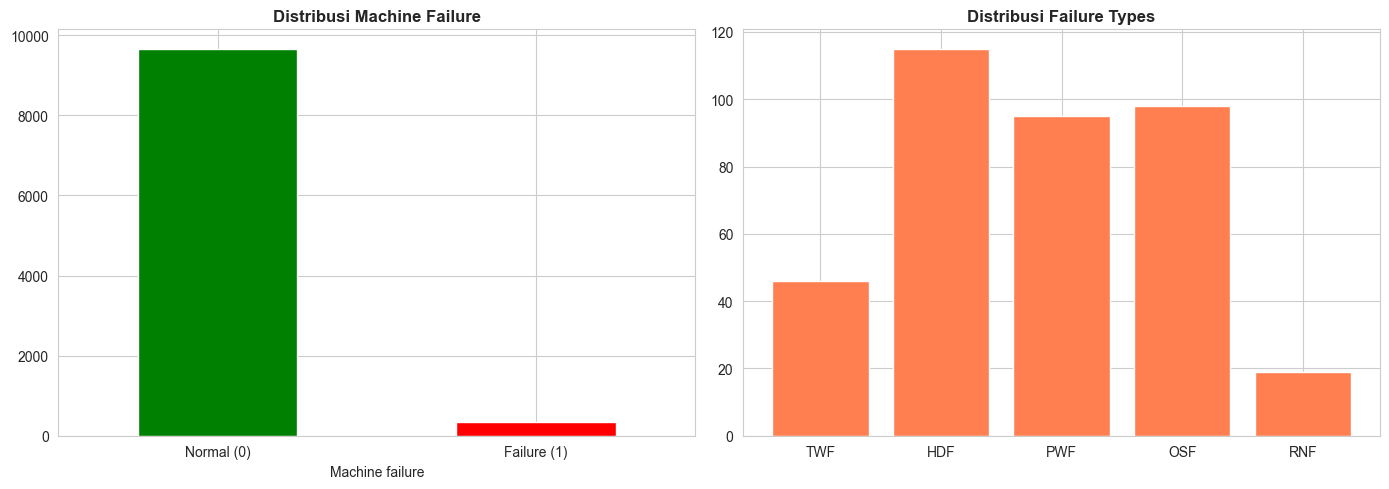

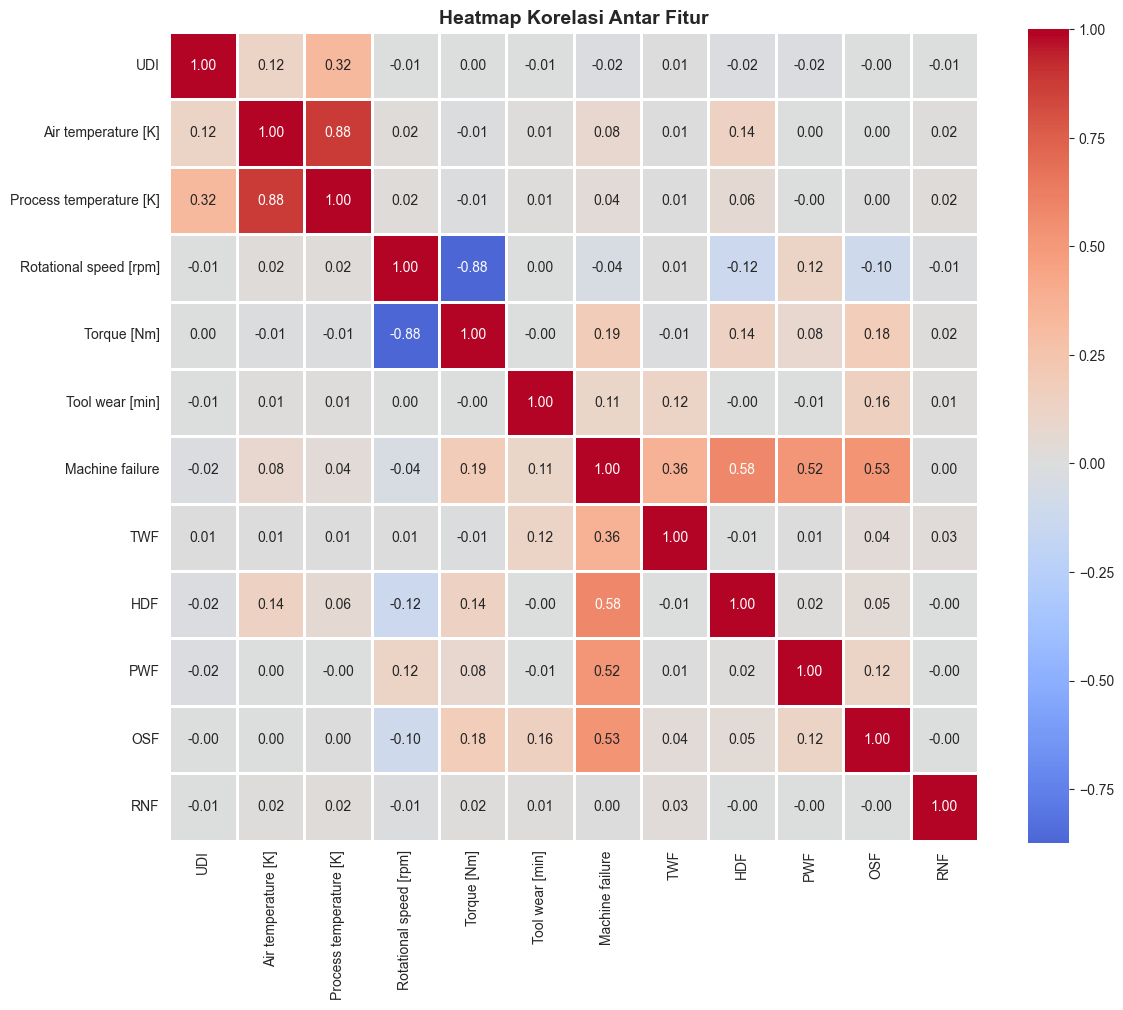

In [5]:
# ============================================================
# EDA
# ============================================================
failure_types = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

# Statistik deskriptif
print(df.describe())

# Distribusi Machine Failure
print("\nDistribusi Machine Failure:")
print(df['Machine failure'].value_counts())
print(df['Machine failure'].value_counts(normalize=True) * 100)

# Distribusi Failure Types
print("\nDistribusi Failure Types:")
for ft in failure_types:
    count = df[ft].sum()
    print(f"  {ft}: {count} ({count/len(df)*100:.2f}%)")

# Plot distribusi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['Machine failure'].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Distribusi Machine Failure', fontweight='bold')
axes[0].set_xticklabels(['Normal (0)', 'Failure (1)'], rotation=0)

failure_counts = [df[ft].sum() for ft in failure_types]
axes[1].bar(failure_types, failure_counts, color='coral')
axes[1].set_title('Distribusi Failure Types', fontweight='bold')

plt.tight_layout()
plt.show()

# Heatmap korelasi
plt.figure(figsize=(12, 10))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(),
            annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1)
plt.title('Heatmap Korelasi Antar Fitur', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Preprocessing

In [6]:
# ============================================================
# PREPROCESSING — disesuaikan dengan API
# Type di-encode pakai LabelEncoder (bukan One-Hot)
# agar konsisten dengan prediction.py
# ============================================================
from sklearn.preprocessing import LabelEncoder

df_processed = df.copy()

# Drop kolom tidak relevan
df_processed = df_processed.drop(columns=['UDI', 'Product ID'])

# LabelEncoder untuk kolom Type (H/L/M → 0/1/2)
le = LabelEncoder()
df_processed['Type'] = le.fit_transform(df_processed['Type'])

print("Mapping Type:", dict(zip(le.classes_, le.transform(le.classes_))))
print("Kolom setelah encoding:")
print(df_processed.columns.tolist())

Mapping Type: {'H': 0, 'L': 1, 'M': 2}
Kolom setelah encoding:
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


# Split & Scaling

In [7]:
# ============================================================
# SPLIT & SCALING — 6 fitur, sesuai urutan di API
# urutan HARUS sama persis dengan input_array di prediction.py
# ============================================================
feature_cols = [
    'Type',                      # index 0 — sesuai API: type_encoded
    'Air temperature [K]',       # index 1
    'Process temperature [K]',   # index 2
    'Rotational speed [rpm]',    # index 3
    'Torque [Nm]',               # index 4
    'Tool wear [min]'            # index 5
]

X = df_processed[feature_cols]
y = df_processed['Machine failure']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=feature_cols,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_cols,
    index=X_test.index
)

print(f"Training set : {X_train.shape[0]} samples")
print(f"Test set     : {X_test.shape[0]} samples")
print(f"Jumlah fitur : {X_train.shape[1]} — {feature_cols}")

Training set : 8000 samples
Test set     : 2000 samples
Jumlah fitur : 6 — ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']


# SMOTE

In [8]:
# ============================================================
# SMOTE — dijalankan dari X_train_SCALED, bukan X_train mentah
# ============================================================
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"Shape sebelum SMOTE : {X_train_scaled.shape}")
print(f"Shape setelah SMOTE : {X_train_resampled.shape}")
print(f"\nDistribusi setelah SMOTE:")
print(pd.Series(y_train_resampled).value_counts())

Shape sebelum SMOTE : (8000, 6)
Shape setelah SMOTE : (15458, 6)

Distribusi setelah SMOTE:
Machine failure
0    7729
1    7729
Name: count, dtype: int64


# Prepare Multiclass Labels

In [9]:
# ============================================================
# PREPARE MULTICLASS LABELS
# Bug #5 fix: tambah penanganan jika satu baris punya
#             lebih dari satu failure type aktif
# Bug #3 fix: definisikan all_class_labels di sini
# ============================================================
failure_types = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
label_map = {'TWF': 0, 'HDF': 1, 'PWF': 2, 'OSF': 3, 'RNF': 4}
all_class_labels = [0, 1, 2, 3, 4]   # <-- Bug #3 fix: didefinisikan di sini

def get_failure_label(row):
    """
    Jika hanya satu failure type aktif → pakai itu.
    Jika lebih dari satu aktif → pakai yang pertama ditemukan (sesuai urutan failure_types).
    Ini lebih eksplisit daripada idxmax() yang diam-diam memilih kolom pertama.
    """
    active = [ft for ft in failure_types if row[ft] == 1]
    if len(active) == 0:
        return None   # baris ini bukan failure — akan difilter
    return label_map[active[0]]

# --- TRAIN ---
train_failure_idx = y_train[y_train == 1].index
failure_df_train  = df_processed.loc[train_failure_idx, failure_types]
y_train_multi     = failure_df_train.apply(get_failure_label, axis=1).dropna().astype(int)
X_train_multi     = X_train_scaled.loc[y_train_multi.index]

# --- TEST ---
test_failure_idx  = y_test[y_test == 1].index
failure_df_test   = df_processed.loc[test_failure_idx, failure_types]
y_test_multi      = failure_df_test.apply(get_failure_label, axis=1).dropna().astype(int)
X_test_multi      = X_test_scaled.loc[y_test_multi.index]

print(f"Failure cases train : {len(X_train_multi)}")
print(f"Failure cases test  : {len(X_test_multi)}")

print("\nDistribusi failure types (train):")
for ft, i in label_map.items():
    count = (y_train_multi == i).sum()
    print(f"  {ft} ({i}): {count} ({count/len(y_train_multi)*100:.1f}%)")

Failure cases train : 264
Failure cases test  : 66

Distribusi failure types (train):
  TWF (0): 36 (13.6%)
  HDF (1): 86 (32.6%)
  PWF (2): 79 (29.9%)
  OSF (3): 63 (23.9%)
  RNF (4): 0 (0.0%)


# Baseline Models

In [10]:
# ============================================================
# BASELINE MODELS — minimal 3 sesuai requirement
# Model: Random Forest, Logistic Regression, Gradient Boosting
# Semua dilatih dari X_train_resampled (post-SMOTE, post-scaling)
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

baseline_models = {
    "Baseline_RandomForest_B"    : RandomForestClassifier(
        n_estimators=100, random_state=42,
        n_jobs=-1, class_weight='balanced'
    ),
    "Baseline_LogisticRegression": LogisticRegression(
        max_iter=1000, random_state=42,
        class_weight='balanced', n_jobs=-1
    ),
    "Baseline_GradientBoosting"  : GradientBoostingClassifier(
        n_estimators=100, random_state=42
    )
}

baseline_results = {}

for model_name, model in baseline_models.items():
    print(f"\n{'='*50}")
    print(f"Training: {model_name}")
    print('='*50)

    model.fit(X_train_resampled, y_train_resampled)

    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    metrics = {
        "accuracy"          : accuracy_score(y_test, y_pred),
        "recall_failure"    : recall_score(y_test, y_pred, pos_label=1, zero_division=0),
        "precision_failure" : precision_score(y_test, y_pred, pos_label=1, zero_division=0),
        "f1_failure"        : f1_score(y_test, y_pred, pos_label=1, zero_division=0),
        "roc_auc"           : roc_auc_score(y_test, y_prob)
    }

    baseline_results[model_name] = metrics

    print(f"  Accuracy          : {metrics['accuracy']:.4f}")
    print(f"  Recall Failure    : {metrics['recall_failure']:.4f}")
    print(f"  Precision Failure : {metrics['precision_failure']:.4f}")
    print(f"  F1-Score Failure  : {metrics['f1_failure']:.4f}")
    print(f"  ROC-AUC           : {metrics['roc_auc']:.4f}")

    with mlflow.start_run(run_name=model_name):
        mlflow.log_param("model_type", model_name)
        mlflow.log_param("training_data", "SMOTE + scaled")
        mlflow.log_params(model.get_params())
        mlflow.log_metrics(metrics)
        mlflow.sklearn.log_model(model, model_name)
        print(f"  → Dicatat ke MLflow.")

# Ringkasan perbandingan baseline
print("\n\n=== RINGKASAN BASELINE ===")
baseline_df = pd.DataFrame(baseline_results).T
print(baseline_df.to_string())


Training: Baseline_RandomForest_B
  Accuracy          : 0.9710
  Recall Failure    : 0.7941
  Precision Failure : 0.5510
  F1-Score Failure  : 0.6506
  ROC-AUC           : 0.9705


2026/04/30 12:53:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/30 12:53:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  → Dicatat ke MLflow.

Training: Baseline_LogisticRegression


2026/04/30 12:53:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/30 12:53:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  Accuracy          : 0.8230
  Recall Failure    : 0.8382
  Precision Failure : 0.1425
  F1-Score Failure  : 0.2436
  ROC-AUC           : 0.9074
  → Dicatat ke MLflow.

Training: Baseline_GradientBoosting


2026/04/30 12:53:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/30 12:53:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  Accuracy          : 0.9295
  Recall Failure    : 0.9118
  Precision Failure : 0.3147
  F1-Score Failure  : 0.4679
  ROC-AUC           : 0.9715
  → Dicatat ke MLflow.


=== RINGKASAN BASELINE ===
                             accuracy  recall_failure  precision_failure  f1_failure   roc_auc
Baseline_RandomForest_B        0.9710        0.794118           0.551020    0.650602  0.970451
Baseline_LogisticRegression    0.8230        0.838235           0.142500    0.243590  0.907358
Baseline_GradientBoosting      0.9295        0.911765           0.314721    0.467925  0.971498


# Optuna Tuning Binary 

In [11]:
# ============================================================
# OPTUNA TUNING — BINARY CLASSIFICATION
# Objective: maximize weighted score (recall + precision)
# ============================================================
def objective_binary(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'        : trial.suggest_int('max_depth', 5, 15),
        'min_samples_split': trial.suggest_int('min_samples_split', 5, 20),
        'min_samples_leaf' : trial.suggest_int('min_samples_leaf', 2, 10),
        'max_features'     : trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'class_weight'     : trial.suggest_categorical('class_weight', ['balanced', 'balanced_subsample']),
        'random_state': 42, 'n_jobs': -1
    }
    model = RandomForestClassifier(**params)
    cv    = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    y_pred = cross_val_predict(model, X_train_resampled, y_train_resampled, cv=cv)

    recall    = recall_score(y_train_resampled, y_pred, pos_label=1, zero_division=0)
    precision = precision_score(y_train_resampled, y_pred, pos_label=1, zero_division=0)
    return (0.85 * recall) + (0.15 * precision)

study_binary = optuna.create_study(direction='maximize', study_name='binary_recall')
study_binary.optimize(objective_binary, n_trials=50, show_progress_bar=True)

print(f"\nBest CV Score : {study_binary.best_value:.4f}")
print("Best Params   :", study_binary.best_params)

# Train ulang dengan best params
best_params_binary = {**study_binary.best_params, 'random_state': 42, 'n_jobs': -1}
rf_binary_tuned = RandomForestClassifier(**best_params_binary)
rf_binary_tuned.fit(X_train_resampled, y_train_resampled)
print("\nModel binary tuned selesai dilatih.")

  0%|          | 0/50 [00:00<?, ?it/s]


Best CV Score : 0.9852
Best Params   : {'n_estimators': 486, 'max_depth': 15, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'class_weight': 'balanced_subsample'}

Model binary tuned selesai dilatih.


# Evaluasi Binary + Threshold Tuning 

In [12]:
# ============================================================
# THRESHOLD TUNING — hanya satu blok, pakai X_test_SCALED
# Bug #4 fix: sebelumnya ada dua blok threshold tuning
#             dengan input berbeda (scaled vs unscaled)
# ============================================================
y_prob_tuned = rf_binary_tuned.predict_proba(X_test_scaled)[:, 1]

thresholds   = np.arange(0.05, 0.90, 0.01)
results      = []

for thresh in thresholds:
    y_pred_t = (y_prob_tuned >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    results.append({
        "threshold" : thresh,
        "recall"    : recall_score(y_test, y_pred_t, pos_label=1, zero_division=0),
        "precision" : precision_score(y_test, y_pred_t, pos_label=1, zero_division=0),
        "f1"        : f1_score(y_test, y_pred_t, pos_label=1, zero_division=0),
        "tn": tn, "fp": fp, "fn": fn, "tp": tp
    })

results_df   = pd.DataFrame(results)
min_precision = 0.30
candidate_df  = results_df[results_df["precision"] >= min_precision]

if len(candidate_df) > 0:
    best_row = candidate_df.sort_values(by=["recall", "f1"], ascending=False).iloc[0]
    strategy = f"Max Recall dengan Precision >= {min_precision}"
else:
    best_row = results_df.sort_values(by=["recall", "f1"], ascending=False).iloc[0]
    strategy = "Fallback: Max Recall tanpa batas precision"

best_threshold    = best_row["threshold"]
y_pred_final      = (y_prob_tuned >= best_threshold).astype(int)

print(f"Strategi  : {strategy}")
print(f"Threshold : {best_threshold:.2f}")
print(f"Recall    : {best_row['recall']:.4f}")
print(f"Precision : {best_row['precision']:.4f}")
print(f"F1        : {best_row['f1']:.4f}")

# Simpan threshold untuk deployment API
os.makedirs("models", exist_ok=True)
with open("models/threshold.pkl", "wb") as f:
    pickle.dump(float(best_threshold), f)
print(f"\nThreshold disimpan ke models/threshold.pkl")

# Log ke MLflow
with mlflow.start_run(run_name="Threshold_Tuning"):
    mlflow.log_param("selection_strategy", strategy)
    mlflow.log_param("default_threshold", 0.50)
    mlflow.log_param("best_threshold", float(best_threshold))
    mlflow.log_param("min_precision_constraint", 0.30)
    mlflow.log_metric("test_recall_failure",    float(best_row['recall']))
    mlflow.log_metric("test_precision_failure", float(best_row['precision']))
    mlflow.log_metric("test_f1_failure",        float(best_row['f1']))
    mlflow.log_metric("test_roc_auc",           float(roc_auc_score(y_test, y_prob_tuned)))
    mlflow.sklearn.log_model(rf_binary_tuned, "Binary_RandomForest_Op")
    print("Dicatat ke MLflow — Threshold_Tuning.")

2026/04/30 12:56:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/30 12:56:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Strategi  : Max Recall dengan Precision >= 0.3
Threshold : 0.24
Recall    : 0.9265
Precision : 0.3214
F1        : 0.4773

Threshold disimpan ke models/threshold.pkl
Dicatat ke MLflow — Threshold_Tuning.


# Optuna Tuning Multiclass + Evaluasi Final

In [14]:
# ============================================================
# OPTUNA TUNING — MULTICLASS
# ============================================================
def objective_multiclass(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'        : trial.suggest_int('max_depth', 3, 25),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf' : trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features'     : trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'class_weight'     : trial.suggest_categorical('class_weight', ['balanced', 'balanced_subsample']),
        'random_state': 42, 'n_jobs': -1
    }
    model  = RandomForestClassifier(**params)
    cv     = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    y_pred = cross_val_predict(model, X_train_multi, y_train_multi, cv=cv)
    return f1_score(y_train_multi, y_pred, average='macro', zero_division=0)

study_multiclass = optuna.create_study(direction='maximize', study_name='multiclass_f1macro')
study_multiclass.optimize(objective_multiclass, n_trials=50, show_progress_bar=True)

best_params_multi   = {**study_multiclass.best_params, 'random_state': 42, 'n_jobs': -1}
rf_multiclass_tuned = RandomForestClassifier(**best_params_multi)
rf_multiclass_tuned.fit(X_train_multi, y_train_multi)

y_pred_multi = rf_multiclass_tuned.predict(X_test_multi)

# ============================================================
# EVALUASI FINAL — BINARY + MULTICLASS
# ============================================================
print("=" * 60)
print("        EVALUASI FINAL MODEL FAULTSENSE")
print("=" * 60)

acc_val    = accuracy_score(y_test, y_pred_final)
recall_val = recall_score(y_test, y_pred_final, pos_label=1, zero_division=0)
f1_bin_val = f1_score(y_test, y_pred_final, pos_label=1, zero_division=0)
auc_val    = roc_auc_score(y_test, y_prob_tuned)
f1_mac_val = f1_score(y_test_multi, y_pred_multi,
                      average='macro', labels=all_class_labels, zero_division=0)

print(f"\nBINARY CLASSIFICATION")
print(f"  Accuracy        : {acc_val:.4f}")
print(f"  Recall Failure  : {recall_val:.4f}")
print(f"  F1-Score Failure: {f1_bin_val:.4f}")
print(f"  ROC-AUC         : {auc_val:.4f}")
print(f"  Threshold       : {best_threshold:.2f}")

print(f"\nMULTICLASS CLASSIFICATION (Jenis Failure)")
print(f"  F1-Macro        : {f1_mac_val:.4f}")

print(f"\n--- Classification Report Binary ---")
print(classification_report(y_test, y_pred_final,
      target_names=['Normal', 'Failure'], zero_division=0))

print(f"\n--- Classification Report Multiclass ---")
print(classification_report(y_test_multi, y_pred_multi,
      labels=all_class_labels, target_names=failure_types, zero_division=0))

# ============================================================
# MLFLOW — pisah jadi dua run sesuai struktur yang ada
# ============================================================

# Run 1: Multiclass Model
with mlflow.start_run(run_name="Multiclass_Model_Optuna"):
    mlflow.log_params(best_params_multi)
    mlflow.log_metric("best_f1_macro_cv", float(study_multiclass.best_value))
    mlflow.log_metric("test_f1_macro",    float(f1_mac_val))
    mlflow.sklearn.log_model(rf_multiclass_tuned, "model_multiclass_rf")
    print("Dicatat ke MLflow — Multiclass_Model_Optuna.")

# Run 2: Final Artifacts — semua metrik final + semua model
with mlflow.start_run(run_name="Final_Artifacts"):
    mlflow.log_param("best_threshold",     float(best_threshold))
    mlflow.log_param("threshold_strategy", strategy)

    mlflow.log_metric("final_accuracy",             float(acc_val))
    mlflow.log_metric("final_recall_failure",       float(recall_val))
    mlflow.log_metric("final_f1_failure",           float(f1_bin_val))
    mlflow.log_metric("final_roc_auc",              float(auc_val))
    mlflow.log_metric("final_f1_macro_multiclass",  float(f1_mac_val))

    mlflow.sklearn.log_model(rf_binary_tuned,    "model_binary_rf")
    mlflow.sklearn.log_model(rf_multiclass_tuned,"model_multiclass_rf")

    mlflow.log_artifact(os.path.join(MODEL_DIR,  "threshold.pkl"))

    print("Dicatat ke MLflow — Final_Artifacts.")

  0%|          | 0/50 [00:00<?, ?it/s]

2026/04/30 12:59:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/30 12:59:19 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


        EVALUASI FINAL MODEL FAULTSENSE

BINARY CLASSIFICATION
  Accuracy        : 0.9310
  Recall Failure  : 0.9265
  F1-Score Failure: 0.4773
  ROC-AUC         : 0.9777
  Threshold       : 0.24

MULTICLASS CLASSIFICATION (Jenis Failure)
  F1-Macro        : 0.6943

--- Classification Report Binary ---
              precision    recall  f1-score   support

      Normal       1.00      0.93      0.96      1932
     Failure       0.32      0.93      0.48        68

    accuracy                           0.93      2000
   macro avg       0.66      0.93      0.72      2000
weighted avg       0.97      0.93      0.95      2000


--- Classification Report Multiclass ---
              precision    recall  f1-score   support

         TWF       0.69      0.90      0.78        10
         HDF       1.00      0.83      0.91        29
         PWF       0.85      0.92      0.88        12
         OSF       0.88      0.93      0.90        15
         RNF       0.00      0.00      0.00         0

 

2026/04/30 12:59:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/30 12:59:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Dicatat ke MLflow — Multiclass_Model_Optuna.


2026/04/30 12:59:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/30 12:59:27 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Dicatat ke MLflow — Final_Artifacts.


# Visualisasi Evaluasi Model

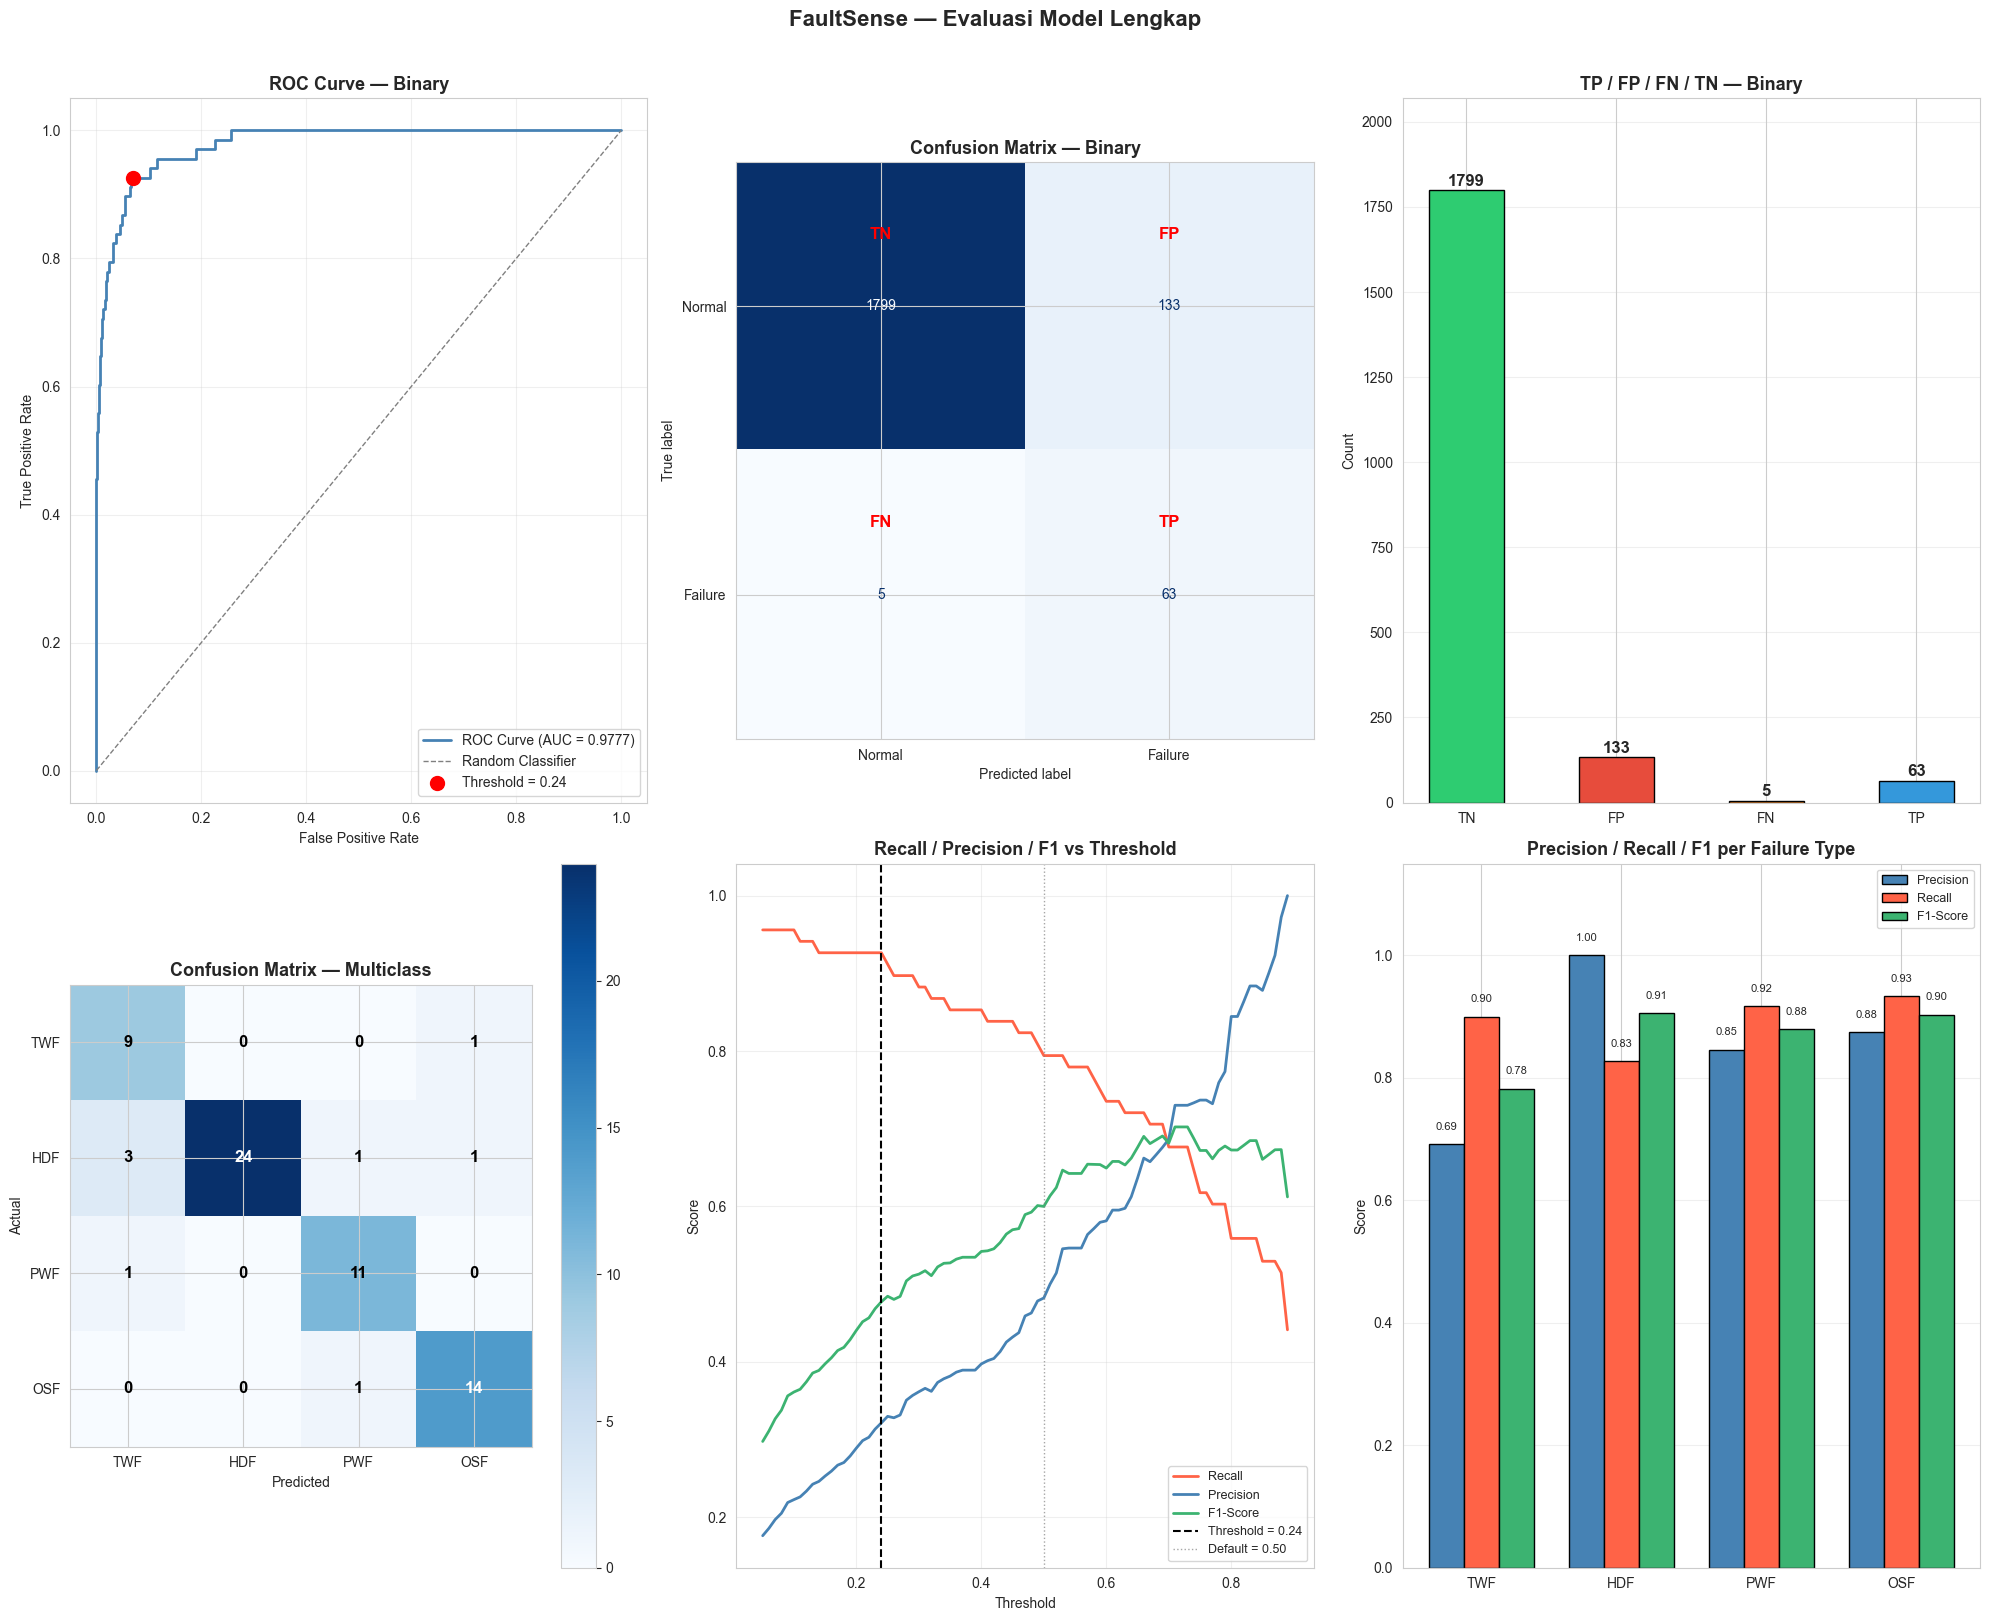

Visualisasi disimpan ke outputs/evaluasi_model_lengkap.png


In [15]:
# ============================================================
# VISUALISASI EVALUASI MODEL
# ============================================================
from sklearn.metrics import roc_curve, auc, ConfusionMatrixDisplay

fig = plt.figure(figsize=(20, 16))

# ============================================================
# 1. ROC CURVE - BINARY
# ============================================================
ax1 = fig.add_subplot(2, 3, 1)
fpr, tpr, _ = roc_curve(y_test, y_prob_tuned)
roc_auc = auc(fpr, tpr)

ax1.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax1.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1, label='Random Classifier')
ax1.scatter(
    best_row['fp'] / (best_row['fp'] + best_row['tn']),
    best_row['tp'] / (best_row['tp'] + best_row['fn']),
    color='red', s=100, zorder=5, label=f'Threshold = {best_threshold:.2f}'
)
ax1.set_title('ROC Curve — Binary', fontweight='bold', fontsize=13)
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend()
ax1.grid(alpha=0.3)

# ============================================================
# 2. CONFUSION MATRIX - BINARY
# ============================================================
ax2 = fig.add_subplot(2, 3, 2)
cm_bin = confusion_matrix(y_test, y_pred_final)
tn, fp, fn, tp = cm_bin.ravel()

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_bin,
    display_labels=['Normal', 'Failure']
)
disp.plot(ax=ax2, cmap='Blues', colorbar=False, values_format='d')
ax2.set_title('Confusion Matrix — Binary', fontweight='bold', fontsize=13)

# Tambah label TP/TN/FP/FN
for (i, j), val in np.ndenumerate(cm_bin):
    label = {(0,0): 'TN', (0,1): 'FP', (1,0): 'FN', (1,1): 'TP'}[(i,j)]
    ax2.text(j, i - 0.25, label, ha='center', va='center',
             fontsize=12, fontweight='bold', color='red')

# ============================================================
# 3. TP / FP / FN / TN BAR CHART - BINARY
# ============================================================
ax3 = fig.add_subplot(2, 3, 3)
labels_bar = ['TN', 'FP', 'FN', 'TP']
values_bar = [tn, fp, fn, tp]
colors_bar = ['#2ecc71', '#e74c3c', '#e67e22', '#3498db']

bars = ax3.bar(labels_bar, values_bar, color=colors_bar, edgecolor='black', width=0.5)
ax3.set_title('TP / FP / FN / TN — Binary', fontweight='bold', fontsize=13)
ax3.set_ylabel('Count')

for bar, val in zip(bars, values_bar):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha='center', va='bottom', fontsize=12, fontweight='bold')

ax3.set_ylim(0, max(values_bar) * 1.15)
ax3.grid(axis='y', alpha=0.3)

# ============================================================
# 4. CONFUSION MATRIX - MULTICLASS
# ============================================================
ax4 = fig.add_subplot(2, 3, 4)

classes_in_test = sorted(y_test_multi.unique())
labels_in_test  = [failure_types[i] for i in classes_in_test]
cm_multi = confusion_matrix(y_test_multi, y_pred_multi, labels=classes_in_test)

im = ax4.imshow(cm_multi, cmap='Blues')
ax4.set_title('Confusion Matrix — Multiclass', fontweight='bold', fontsize=13)
ax4.set_xticks(range(len(classes_in_test)))
ax4.set_yticks(range(len(classes_in_test)))
ax4.set_xticklabels(labels_in_test)
ax4.set_yticklabels(labels_in_test)
ax4.set_xlabel('Predicted')
ax4.set_ylabel('Actual')

for i in range(len(classes_in_test)):
    for j in range(len(classes_in_test)):
        ax4.text(j, i, cm_multi[i, j], ha='center', va='center',
                 fontsize=12, fontweight='bold',
                 color='white' if cm_multi[i, j] > cm_multi.max()/2 else 'black')

plt.colorbar(im, ax=ax4)

# ============================================================
# 5. RECALL / PRECISION / F1 VS THRESHOLD
# ============================================================
ax5 = fig.add_subplot(2, 3, 5)
ax5.plot(results_df["threshold"], results_df["recall"],    label='Recall',    color='tomato',       lw=2)
ax5.plot(results_df["threshold"], results_df["precision"], label='Precision', color='steelblue',    lw=2)
ax5.plot(results_df["threshold"], results_df["f1"],        label='F1-Score',  color='mediumseagreen', lw=2)
ax5.axvline(x=best_threshold, color='black', linestyle='--', lw=1.5,
            label=f'Threshold = {best_threshold:.2f}')
ax5.axvline(x=0.50, color='gray', linestyle=':', lw=1, label='Default = 0.50', alpha=0.7)
ax5.set_title('Recall / Precision / F1 vs Threshold', fontweight='bold', fontsize=13)
ax5.set_xlabel('Threshold')
ax5.set_ylabel('Score')
ax5.legend(fontsize=9)
ax5.grid(alpha=0.3)

# ============================================================
# 6. F1 PER FAILURE TYPE - MULTICLASS
# ============================================================
ax6 = fig.add_subplot(2, 3, 6)

report = classification_report(
    y_test_multi, y_pred_multi,
    labels=classes_in_test,
    target_names=labels_in_test,
    zero_division=0,
    output_dict=True
)

f1_per_class     = [report[ft]['f1-score'] for ft in labels_in_test]
recall_per_class = [report[ft]['recall']   for ft in labels_in_test]
prec_per_class   = [report[ft]['precision'] for ft in labels_in_test]

x      = np.arange(len(labels_in_test))
width  = 0.25

ax6.bar(x - width, prec_per_class, width, label='Precision', color='steelblue',     edgecolor='black')
ax6.bar(x,         recall_per_class, width, label='Recall',  color='tomato',        edgecolor='black')
ax6.bar(x + width, f1_per_class,   width, label='F1-Score',  color='mediumseagreen', edgecolor='black')

ax6.set_title('Precision / Recall / F1 per Failure Type', fontweight='bold', fontsize=13)
ax6.set_xticks(x)
ax6.set_xticklabels(labels_in_test)
ax6.set_ylabel('Score')
ax6.set_ylim(0, 1.15)
ax6.legend(fontsize=9)
ax6.grid(axis='y', alpha=0.3)

for bars in [ax6.containers[0], ax6.containers[1], ax6.containers[2]]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax6.text(bar.get_x() + bar.get_width()/2, h + 0.02,
                     f'{h:.2f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('FaultSense — Evaluasi Model Lengkap', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()

# Simpan
os.makedirs("outputs", exist_ok=True)
plt.savefig("outputs/evaluasi_model_lengkap.png", dpi=150, bbox_inches='tight')
plt.show()

print("Visualisasi disimpan ke outputs/evaluasi_model_lengkap.png")

# Save Model

In [16]:
# ============================================================
# SIMPAN MODEL — label_encoder fit dari kolom Type
# sesuai yang dipakai di prediction.py
# ============================================================
os.makedirs("models", exist_ok=True)

# le sudah di-fit dari df['Type'] di Section 5
# classes_ = ['H', 'L', 'M'] → transform('H')=0, dst.
with open(os.path.join(MODEL_DIR, "label_encoder.pkl"), "wb") as f:
    pickle.dump(le, f)

with open(os.path.join(MODEL_DIR, "scaler.pkl"), "wb") as f:
    pickle.dump(scaler, f)

with open(os.path.join(MODEL_DIR, "model_binary_rf.pkl"), "wb") as f:
    pickle.dump(rf_binary_tuned, f)

with open(os.path.join(MODEL_DIR, "model_multiclass_rf.pkl"), "wb") as f:
    pickle.dump(rf_multiclass_tuned, f)

with open(os.path.join(MODEL_DIR, "threshold.pkl"), "wb") as f:
    pickle.dump(float(best_threshold), f)

# Verifikasi
print("Verifikasi label_encoder:")
for cls in le.classes_:
    print(f"  '{cls}' → {le.transform([cls])[0]}")

print(f"\nVerifikasi scaler    : n_features_in_ = {scaler.n_features_in_} (harus 6)")
print(f"Verifikasi binary    : n_features_in_ = {rf_binary_tuned.n_features_in_} (harus 6)")

print("\nSemua model disimpan:")
for fname in ["label_encoder.pkl", "scaler.pkl", "model_binary_rf.pkl",
              "model_multiclass_rf.pkl", "threshold.pkl"]:
    path = os.path.join(MODEL_DIR, fname)
    size = os.path.getsize(path)
    print(f"  {fname} ({size/1024:.1f} KB)")

Verifikasi label_encoder:
  'H' → 0
  'L' → 1
  'M' → 2

Verifikasi scaler    : n_features_in_ = 6 (harus 6)
Verifikasi binary    : n_features_in_ = 6 (harus 6)

Semua model disimpan:
  label_encoder.pkl (0.2 KB)
  scaler.pkl (0.8 KB)
  model_binary_rf.pkl (29266.5 KB)
  model_multiclass_rf.pkl (591.2 KB)
  threshold.pkl (0.0 KB)
